<a href="https://colab.research.google.com/github/SergeiVKalinin/Probabilistic-Unmixing-0/blob/main/notebooks/05_Uncertainty_Tradeoff_Sweep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 05 — Concentration–Spectral Uncertainty Trade-off Sweep

This notebook turns the heterogeneous example into a small **information-regime map**.

We vary the concentration uncertainty and spectral uncertainty of **Component 4** while keeping the underlying physical experiment fixed.

The same seed is used at every grid point, so the true endmembers, true fractions, measured spectra, and measurement noise remain unchanged.

Only the prior information supplied to inference changes.

To keep the notebook fast enough for interactive use, the default sweep is a 3 × 3 grid. Increase the grid density after the workflow is understood.

In [1]:
!pip install -q --force-reinstall --no-deps git+https://github.com/SergeiVKalinin/Probabilistic-Unmixing-0.git

import numpy as np
import matplotlib.pyplot as plt
import probunmix as pu

print("probunmix version:", pu.__version__)

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
probunmix version: 0.1.0


## Define the sweep

Components 1–3 remain at the canonical uncertainty scale. Component 4 is moved from well known to poorly known along two independent axes.

In [2]:
concentration_grid = np.array([0.01, 0.05, 0.12])
spectral_grid = np.array([0.30, 1.00, 2.50])

target = 3  # Component 4, zero-based index

base_W = np.array([0.03, 0.03, 0.03, 0.03])
base_S = np.array([1.00, 1.00, 1.00, 1.00])

sweep_rows = []

## Verify the matched-experiment property

Before fitting the grid, check two opposite corners. The physical data should be identical even though the prior uncertainties differ.

In [3]:
a = pu.generate_example(
    n_locations=24, n_channels=60, n_library=40,
    concentration_uncertainty=[0.03, 0.03, 0.03, 0.01],
    spectral_uncertainty=[1.0, 1.0, 1.0, 0.30],
    seed=2026,
)

b = pu.generate_example(
    n_locations=24, n_channels=60, n_library=40,
    concentration_uncertainty=[0.03, 0.03, 0.03, 0.12],
    spectral_uncertainty=[1.0, 1.0, 1.0, 2.50],
    seed=2026,
)

print("W_true identical:", np.allclose(a.W_true, b.W_true))
print("S_true identical:", np.allclose(a.S_true, b.S_true))
print("Y identical:", np.allclose(a.Y, b.Y))
print("W uncertainty differs:", not np.allclose(a.W_sigma, b.W_sigma))
print("Spectral library differs:", not np.allclose(a.S_library, b.S_library))

W_true identical: True
S_true identical: True
Y identical: True
W uncertainty differs: True
Spectral library differs: True


## Run Level 1 and Level 2 over the grid

This cell performs 18 small fits. It is intentionally smaller than the canonical examples so that the sweep remains practical in Colab.

In [4]:
sweep_rows = []

for w_sd in concentration_grid:
    for s_scale in spectral_grid:
        W_unc = base_W.copy()
        S_unc = base_S.copy()
        W_unc[target] = w_sd
        S_unc[target] = s_scale

        d = pu.generate_example(
            n_locations=24,
            n_channels=60,
            n_library=40,
            concentration_uncertainty=W_unc,
            spectral_uncertainty=S_unc,
            seed=2026,
        )

        r1 = pu.fit(
            d, level=1, n_draws=100, seed=1001, max_nfev=120
        )
        r2 = pu.fit(
            d, level=2, n_draws=100, seed=1002, max_nfev=120
        )

        row = {
            "concentration_sd": w_sd,
            "spectral_scale": s_scale,
        }

        for r in [r1, r2]:
            L = r.level
            row[f"L{L}_W_RMSE"] = np.sqrt(
                np.mean((r.W_mean[:, target] - d.W_true[:, target])**2)
            )
            row[f"L{L}_W_SD"] = r.W_sd[:, target].mean()
            row[f"L{L}_S_RMSE"] = np.sqrt(
                np.mean((r.S_mean[target] - d.S_true[target])**2)
            )
            row[f"L{L}_S_SD"] = r.S_sd[target].mean()

        sweep_rows.append(row)

import pandas as pd
sweep = pd.DataFrame(sweep_rows)
sweep

,concentration_sd,spectral_scale,L1_W_RMSE,L1_W_SD,L1_S_RMSE,L1_S_SD,L2_W_RMSE,L2_W_SD,L2_S_RMSE,L2_S_SD
0,0.01,0.3,0.012423,0.008255,0.006608,0.001970,0.012105,0.007910,0.006578,0.001806
1,0.01,1.0,0.011807,0.008235,0.006360,0.001964,0.011983,0.007803,0.006410,0.002170
2,0.01,2.5,0.012025,0.008236,0.006206,0.002003,0.012872,0.008191,0.006642,0.003416
3,0.05,0.3,0.013762,0.010424,0.005604,0.001918,0.013909,0.009941,0.005761,0.001819
4,0.05,1.0,0.013697,0.010536,0.005147,0.002008,0.013517,0.009860,0.005511,0.002222
5,0.05,2.5,0.013635,0.010639,0.005168,0.002062,0.013520,0.010484,0.005061,0.003669
6,0.12,0.3,0.016910,0.011027,0.004503,0.002016,0.016688,0.010558,0.004869,0.001824
7,0.12,1.0,0.015928,0.010779,0.004509,0.002015,0.016171,0.010475,0.004477,0.002249
8,0.12,2.5,0.016008,0.010925,0.004195,0.002058,0.018311,0.011623,0.005156,0.003895


## Visualize the information-regime map

Horizontal movement increases spectral uncertainty. Vertical movement increases concentration uncertainty.

The off-diagonal regions are scientifically important because they compare strong concentration information with weak spectral information, and vice versa.

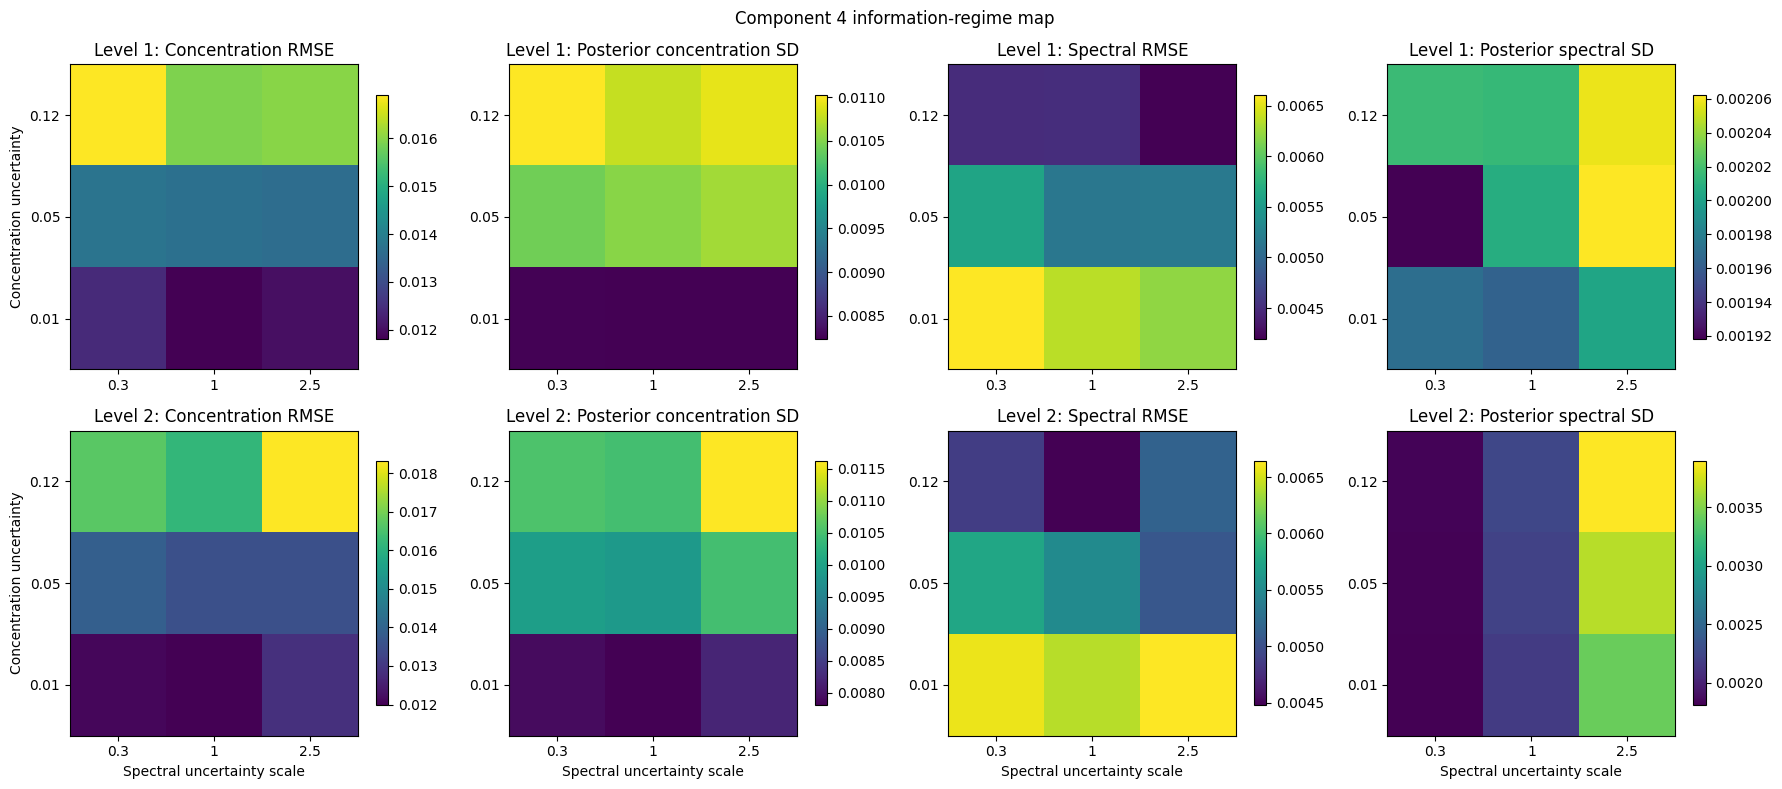

In [5]:
def matrix_for(column):
    return (
        sweep.pivot(
            index="concentration_sd",
            columns="spectral_scale",
            values=column,
        )
        .sort_index()
    )

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

metrics = [
    ("W_RMSE", "Concentration RMSE"),
    ("W_SD", "Posterior concentration SD"),
    ("S_RMSE", "Spectral RMSE"),
    ("S_SD", "Posterior spectral SD"),
]

for row, level in enumerate([1, 2]):
    for col, (metric, title) in enumerate(metrics):
        m = matrix_for(f"L{level}_{metric}")
        ax = axes[row, col]
        image = ax.imshow(m.values, origin="lower", aspect="auto")

        ax.set_xticks(np.arange(len(m.columns)))
        ax.set_xticklabels([f"{v:g}" for v in m.columns])
        ax.set_yticks(np.arange(len(m.index)))
        ax.set_yticklabels([f"{v:g}" for v in m.index])

        ax.set_title(f"Level {level}: {title}")

        if row == 1:
            ax.set_xlabel("Spectral uncertainty scale")
        if col == 0:
            ax.set_ylabel("Concentration uncertainty")

        fig.colorbar(image, ax=ax, shrink=0.8)

fig.suptitle("Component 4 information-regime map")
fig.tight_layout();

## Interpretation

A purely vertical pattern would indicate that concentration uncertainty dominates. A purely horizontal pattern would indicate that spectral uncertainty dominates.

Curved or diagonal structure is more interesting: it indicates a trade-off between information about the fractions and information about the endmember spectrum.

This sweep is intended as a starting point for controlled studies. Increase the number of locations, spectral channels, library members, posterior draws, and grid density only after the qualitative behavior is understood.